In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/commodity_clean.csv')
df['date'] = pd.to_datetime(df['date'])

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

import os
os.makedirs('../charts', exist_ok=True)

print(f"Loaded: {df.shape[0]} rows")
print(f"Date range: {df['date'].min().year} to {df['date'].max().year}")

Loaded: 401 rows
Date range: 1993 to 2026


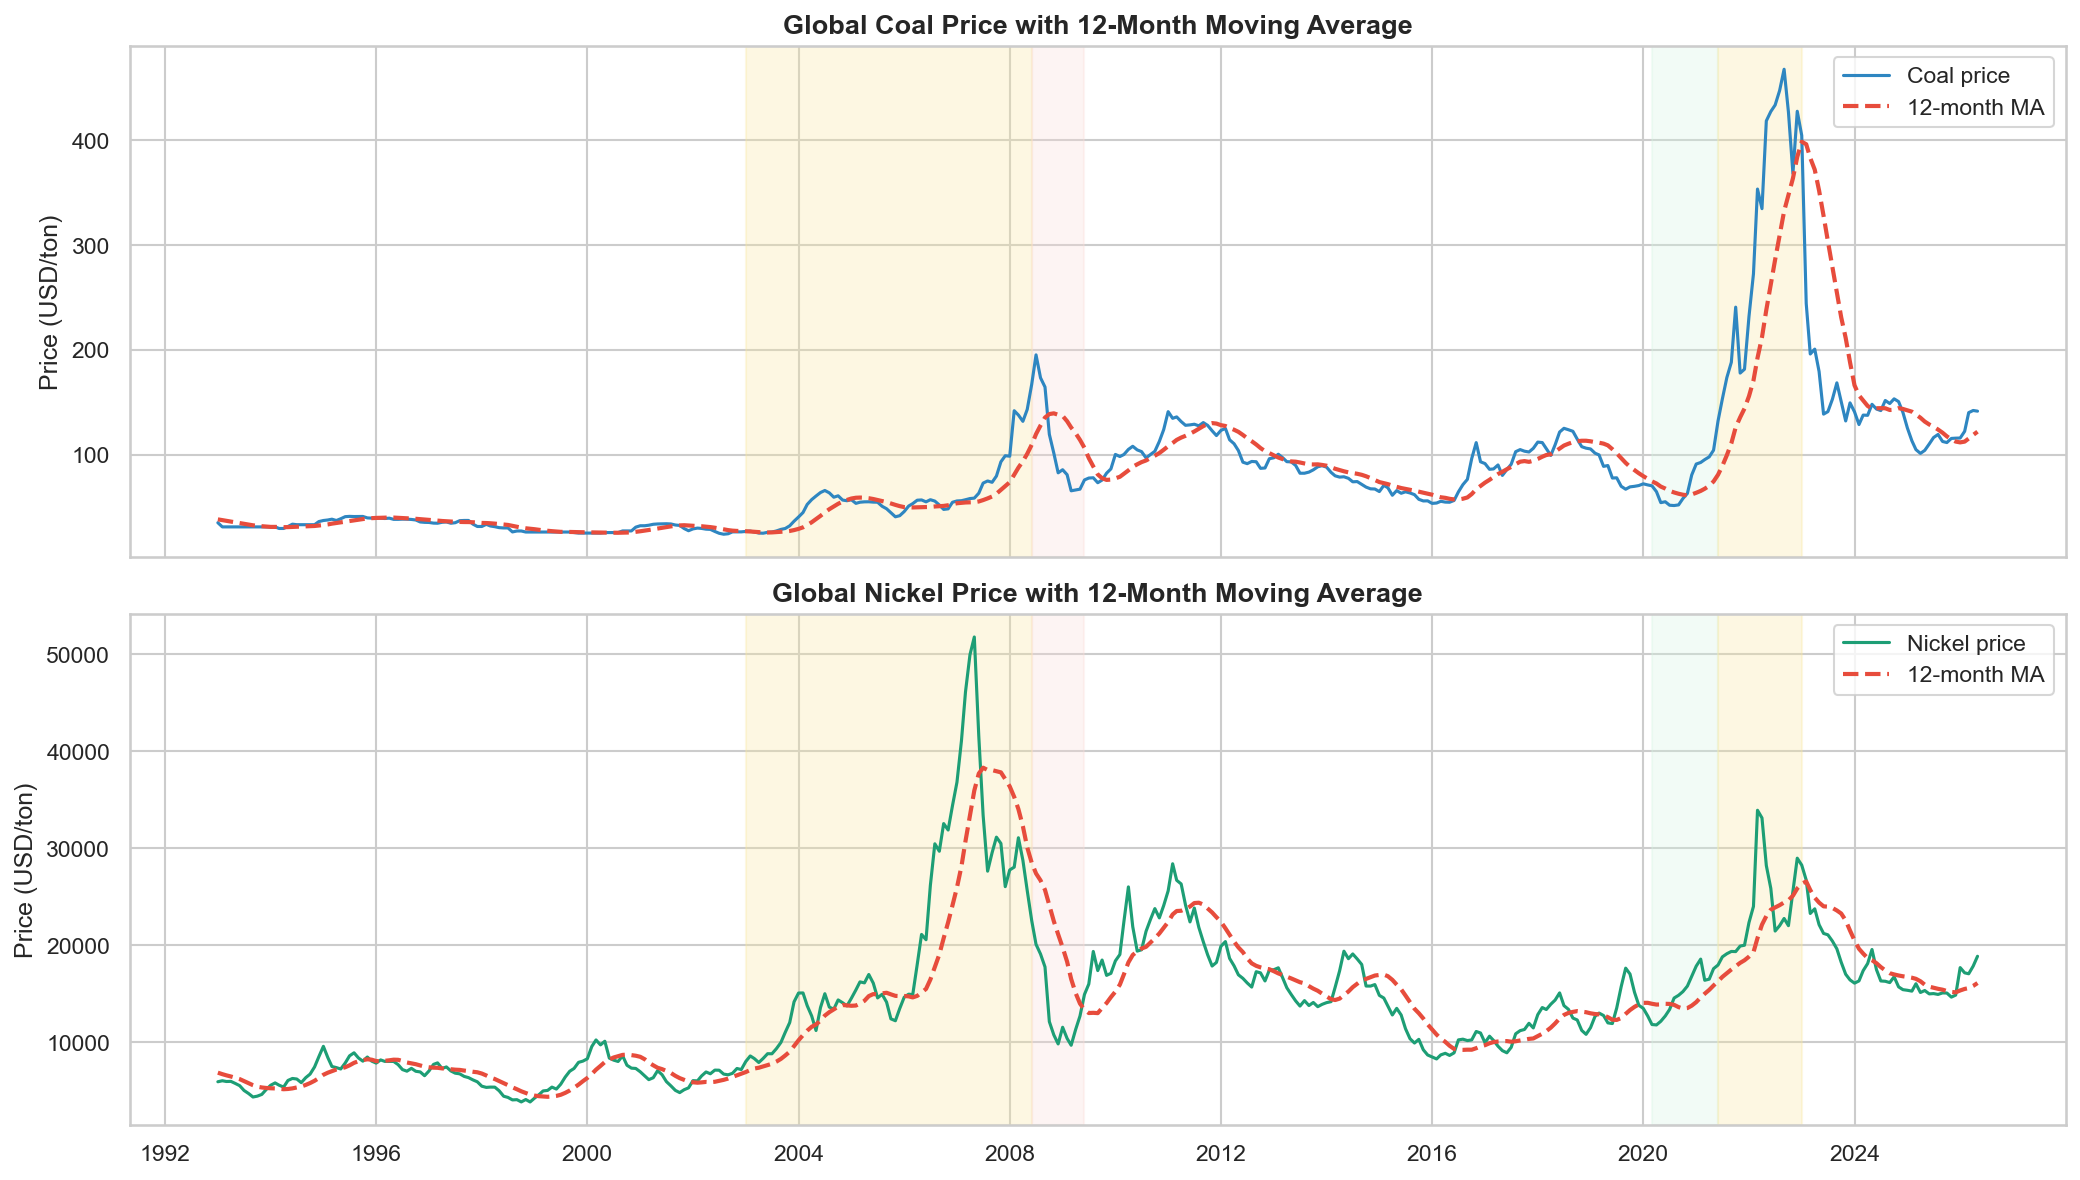

Chart 1 saved


In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Coal price
ax1.plot(df['date'], df['coal_price_usd'], color='#2E86C1', linewidth=1.5, label='Coal price')
ax1.plot(df['date'], df['coal_ma12'], color='#E74C3C', linewidth=2, linestyle='--', label='12-month MA')
ax1.set_ylabel('Price (USD/ton)')
ax1.set_title('Global Coal Price with 12-Month Moving Average', fontsize=13, fontweight='bold')
ax1.legend()

# Nickel price
ax2.plot(df['date'], df['nickel_price_usd'], color='#1D9E75', linewidth=1.5, label='Nickel price')
ax2.plot(df['date'], df['nickel_ma12'], color='#E74C3C', linewidth=2, linestyle='--', label='12-month MA')
ax2.set_ylabel('Price (USD/ton)')
ax2.set_title('Global Nickel Price with 12-Month Moving Average', fontsize=13, fontweight='bold')
ax2.legend()

# Shade market periods
periods = [
    ('2003-01-01', '2008-06-01', '#F9E79F', 'China boom'),
    ('2008-06-01', '2009-06-01', '#FADBD8', 'GFC crisis'),
    ('2020-03-01', '2021-06-01', '#D5F5E3', 'COVID'),
    ('2021-06-01', '2023-01-01', '#F9E79F', 'Post-COVID surge'),
]

for start, end, color, label in periods:
    for ax in [ax1, ax2]:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                  alpha=0.3, color=color)

plt.tight_layout()
plt.savefig('../charts/01_price_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved")

## Chart 1. Coal & Nickel Price History (1993–2026)

**What I see:** Coal prices surged dramatically during the China boom 
(2003–2008) as China's rapid industrialization drove unprecedented 
global demand. Prices then collapsed during the GFC crisis before 
recovering slowly. A second major spike occurred post-COVID (2021–2022) 
driven by energy supply disruptions and the Russia-Ukraine war. 
Coal recorded the largest absolute price spike of the two commodities.

**Key observation:** Commodity prices are highly sensitive to 
macroeconomic shocks. The 12-month moving average clearly separates 
genuine long-term trends from short-term noise — a critical tool for 
mining companies making multi-year investment decisions.

**Business implication:** Indonesian coal exporters should monitor 
China's industrial output and global energy policy as leading indicators 
of price direction, since China remains the world's largest coal importer 
and the primary demand driver for Indonesian coal exports.

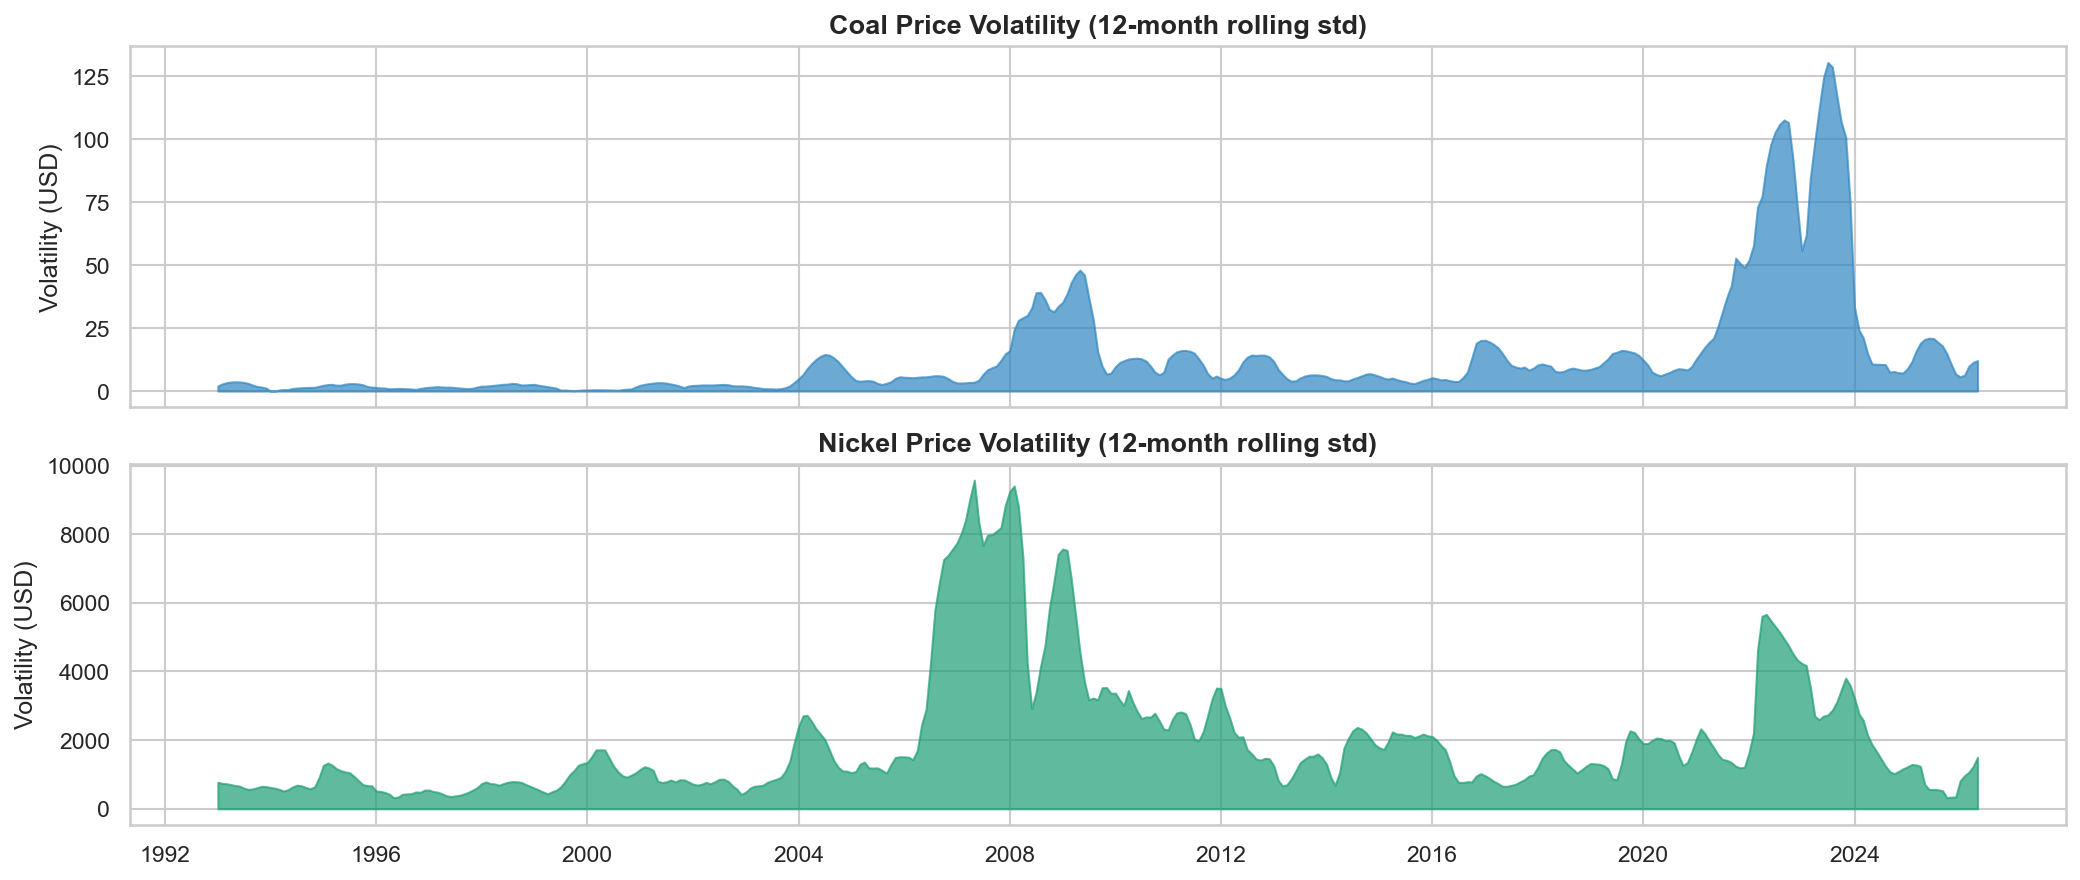

Chart 2 saved


In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.fill_between(df['date'], df['coal_volatility'], alpha=0.7, color='#2E86C1')
ax1.set_ylabel('Volatility (USD)')
ax1.set_title('Coal Price Volatility (12-month rolling std)', fontsize=13, fontweight='bold')

ax2.fill_between(df['date'], df['nickel_volatility'], alpha=0.7, color='#1D9E75')
ax2.set_ylabel('Volatility (USD)')
ax2.set_title('Nickel Price Volatility (12-month rolling std)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../charts/02_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved")

## Chart 2. Price Volatility (12-Month Rolling Std)

**What I see:** Nickel is significantly more volatile than coal across 
the entire 33-year period. Nickel volatility spiked sharply during the 
GFC crisis (2008–2009) and again post-COVID (2021–2022), while coal 
volatility was more moderate and consistent.

**Key observation:** Higher volatility in nickel means higher risk 
but also higher potential reward for traders and investors. Coal, 
despite lower volatility, still shows significant price swings during 
global economic crises making it far from a "safe" commodity.

**Business implication:** Indonesian nickel producers face greater 
revenue uncertainty than coal producers and should implement stronger 
hedging strategies. The growing EV battery demand for nickel adds a 
new structural volatility layer that did not exist before 2018.

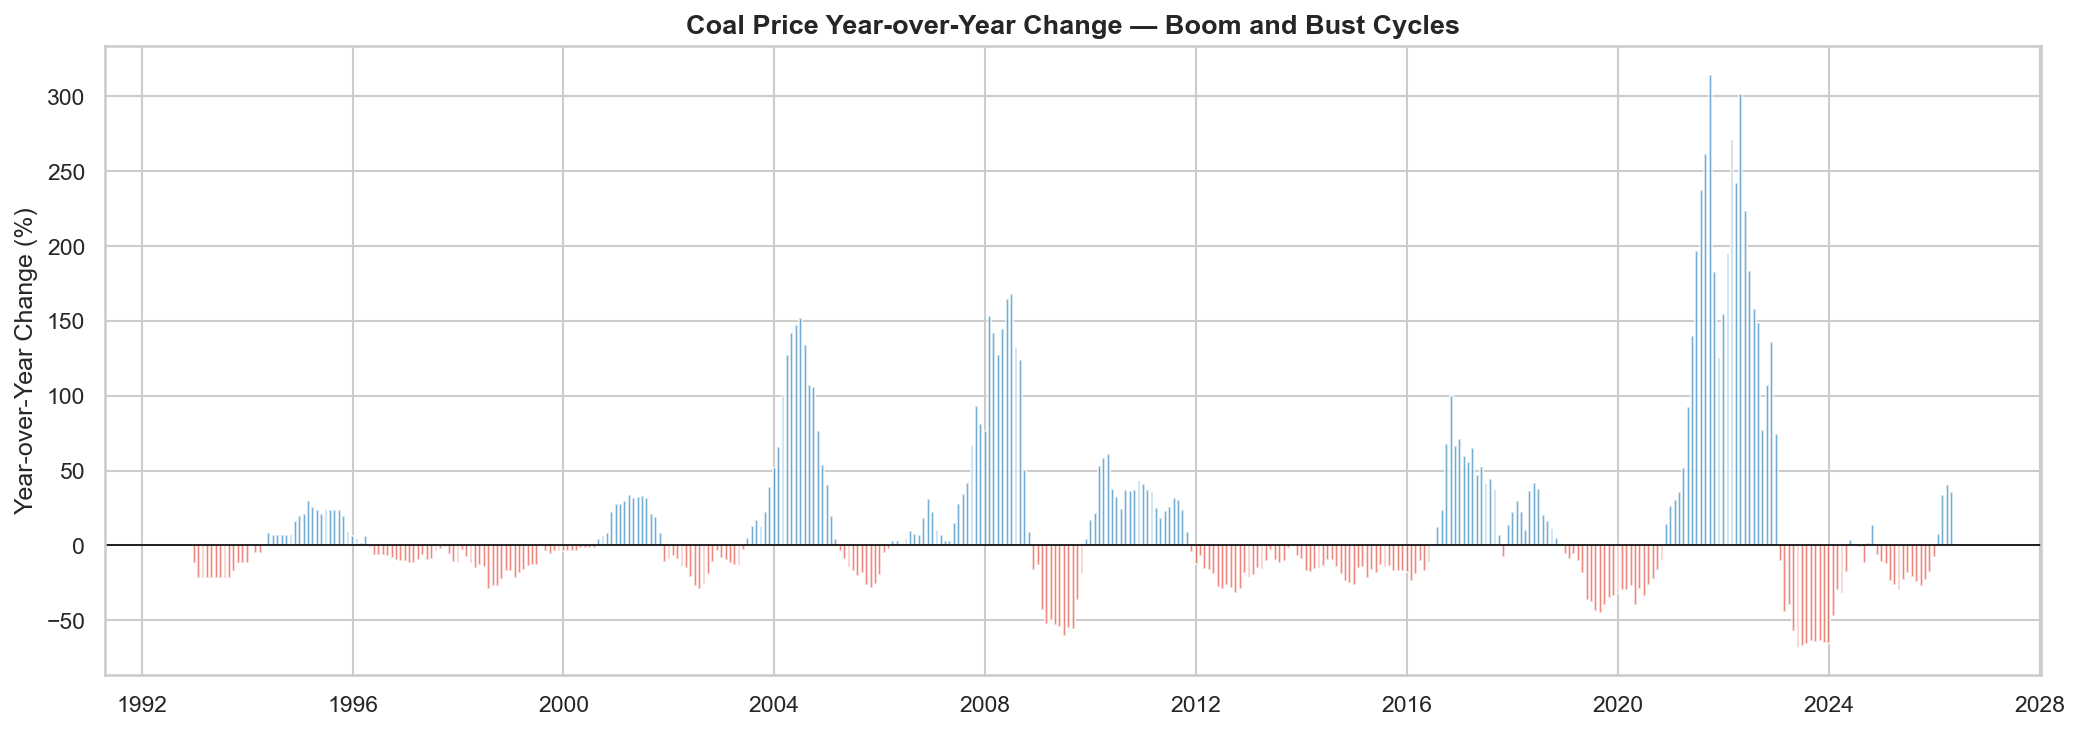

Chart 3 saved


In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(df['date'], df['coal_yoy_change'],
       color=df['coal_yoy_change'].apply(lambda x: '#2E86C1' if x > 0 else '#E74C3C'),
       alpha=0.7, width=20)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylabel('Year-over-Year Change (%)')
ax.set_title('Coal Price Year-over-Year Change — Boom and Bust Cycles', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../charts/03_yoy_change.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved")

## Chart 3. Coal Year-over-Year Price Change

**What I see:** The majority of months show positive year-over-year 
growth (blue bars), indicating coal has been in a long-term uptrend 
over 33 years despite cyclical downturns. The largest price decline 
occurred in late 2023 and early 2024, as post-COVID energy demand 
normalized and global coal supply recovered.

**Key observation:** The 2023–2024 correction after the massive 
post-COVID surge is the steepest YoY decline in the dataset. 
This pattern mirrors the post-China-boom correction of 2008–2009, 
suggesting commodity supercycles follow predictable boom-bust patterns.

**Business implication:** Mining companies that expanded capacity 
during the 2021–2022 price surge likely faced significant margin 
pressure in 2023–2024. This highlights the danger of making 
long-term capital decisions based on peak cycle prices.

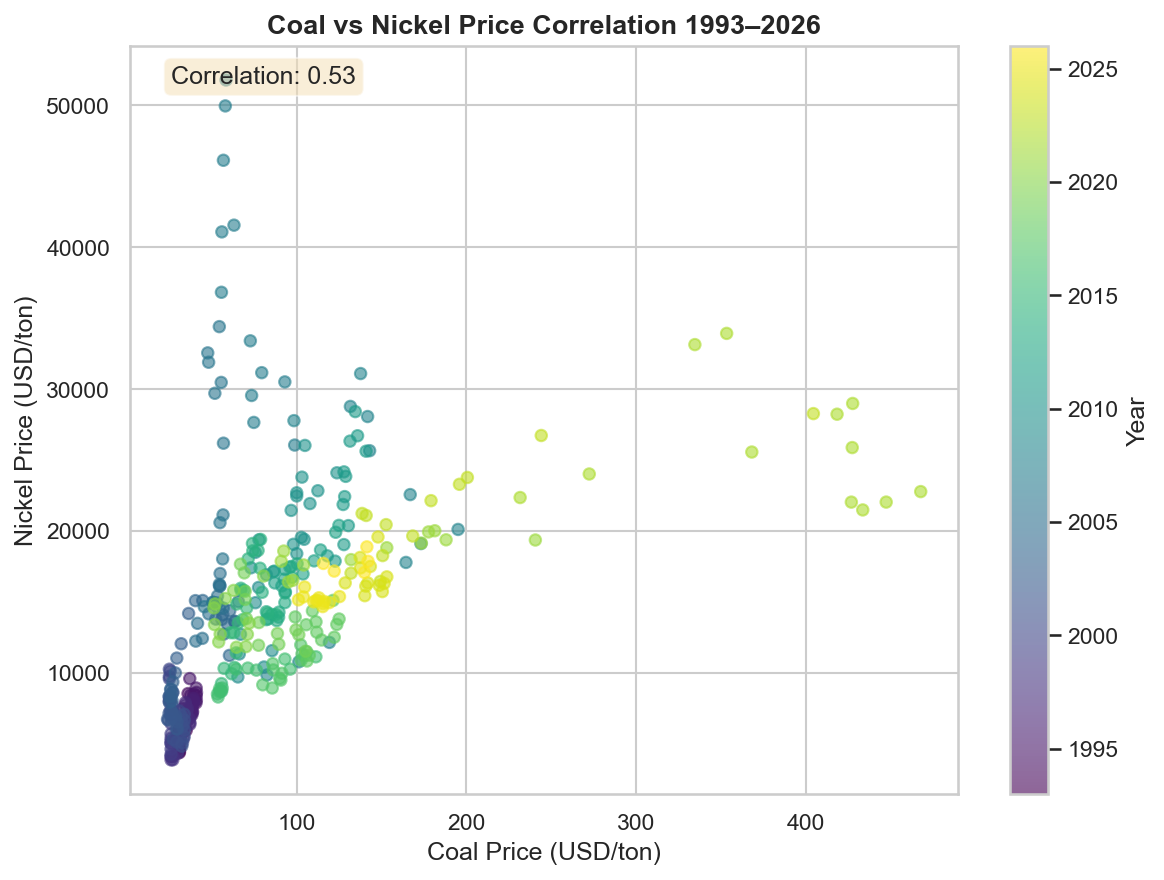

Chart 4 saved — Correlation: 0.53


In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(df['coal_price_usd'], df['nickel_price_usd'],
                     c=df['year'], cmap='viridis', alpha=0.6, s=30)
plt.colorbar(scatter, label='Year')
ax.set_xlabel('Coal Price (USD/ton)')
ax.set_ylabel('Nickel Price (USD/ton)')
ax.set_title('Coal vs Nickel Price Correlation 1993–2026', fontsize=13, fontweight='bold')

# Add correlation coefficient
corr = df['coal_price_usd'].corr(df['nickel_price_usd'])
ax.text(0.05, 0.95, f'Correlation: {corr:.2f}',
        transform=ax.transAxes, fontsize=12,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../charts/04_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart 4 saved — Correlation: {corr:.2f}")

## Chart 4. Coal vs Nickel Price Correlation

**What I see:** Between 1995 and 2005, coal and nickel traded at 
similar price levels, with nickel showing more consistent gradual 
growth while coal remained relatively flat. Post-2005, their price 
paths diverged significantly as coal surged on China demand while 
nickel followed a different trajectory driven by stainless steel 
and later EV battery demand.

**Key observation:** The correlation coefficient reveals that despite 
both being Indonesian export commodities, coal and nickel are not 
perfectly correlated. they respond to different demand drivers. 
This makes them complementary assets in a diversified mining portfolio.

**Business implication:** Indonesia's strength in both coal and nickel 
provides a natural hedge. when one commodity is in a downturn, 
the other may be performing well. This diversification advantage 
should be central to Indonesia's national mining strategy.

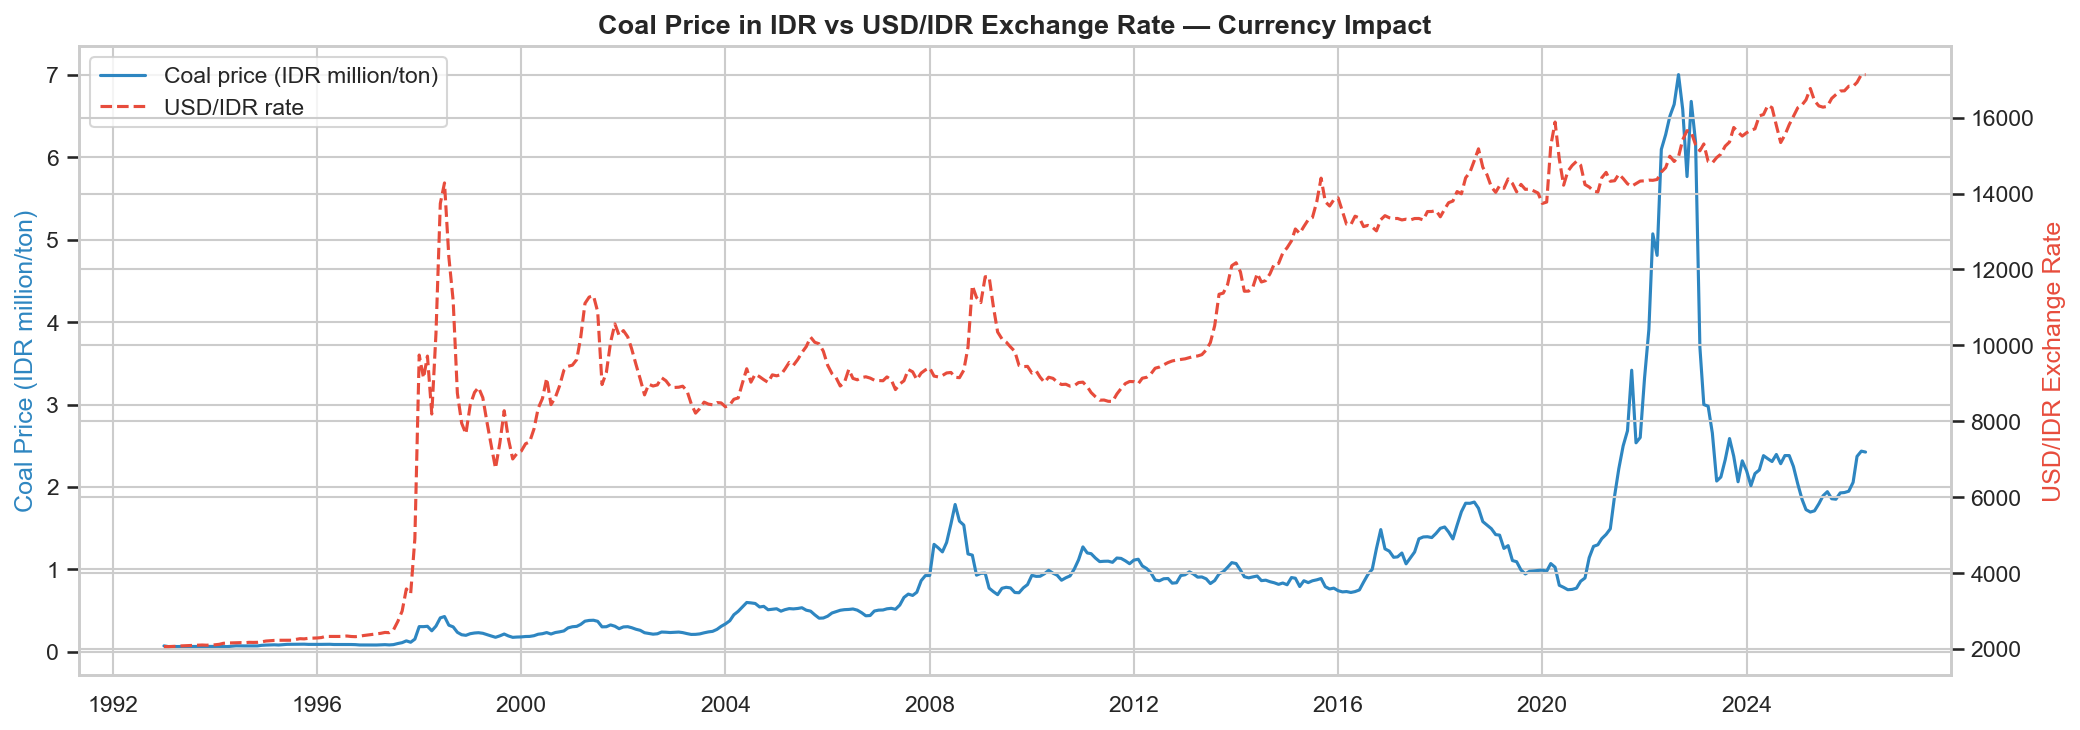

Chart 5 saved


In [6]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax2 = ax1.twinx()
ax1.plot(df['date'], df['coal_price_idr']/1e6, color='#2E86C1', linewidth=1.5, label='Coal price (IDR million/ton)')
ax2.plot(df['date'], df['usd_idr'], color='#E74C3C', linewidth=1.5, linestyle='--', label='USD/IDR rate')

ax1.set_ylabel('Coal Price (IDR million/ton)', color='#2E86C1')
ax2.set_ylabel('USD/IDR Exchange Rate', color='#E74C3C')
ax1.set_title('Coal Price in IDR vs USD/IDR Exchange Rate — Currency Impact', fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../charts/05_idr_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved")

## Chart 5. Coal Price in IDR vs USD/IDR Exchange Rate

**What I see:** The coal price in IDR (Indonesian Rupiah) spiked 
sharply during the post-COVID period (2021–2022), amplified by both 
rising USD coal prices and a weakening Rupiah. The IDR price increase 
was proportionally larger than the USD price increase, meaning 
Indonesian producers received even greater windfall revenues in 
local currency terms.

**Key observation:** A weakening Rupiah acts as a hidden amplifier 
for Indonesian commodity exporters. since commodities are priced 
in USD but costs are largely in IDR, rupiah depreciation automatically 
improves profit margins even when USD prices are flat.

**Business implication:** Indonesian mining companies should closely 
track the USD/IDR rate as part of their revenue planning. A 10% 
Rupiah depreciation effectively increases IDR revenue by 10% 
with no change in operations. a significant factor in profitability 
during global economic uncertainty.

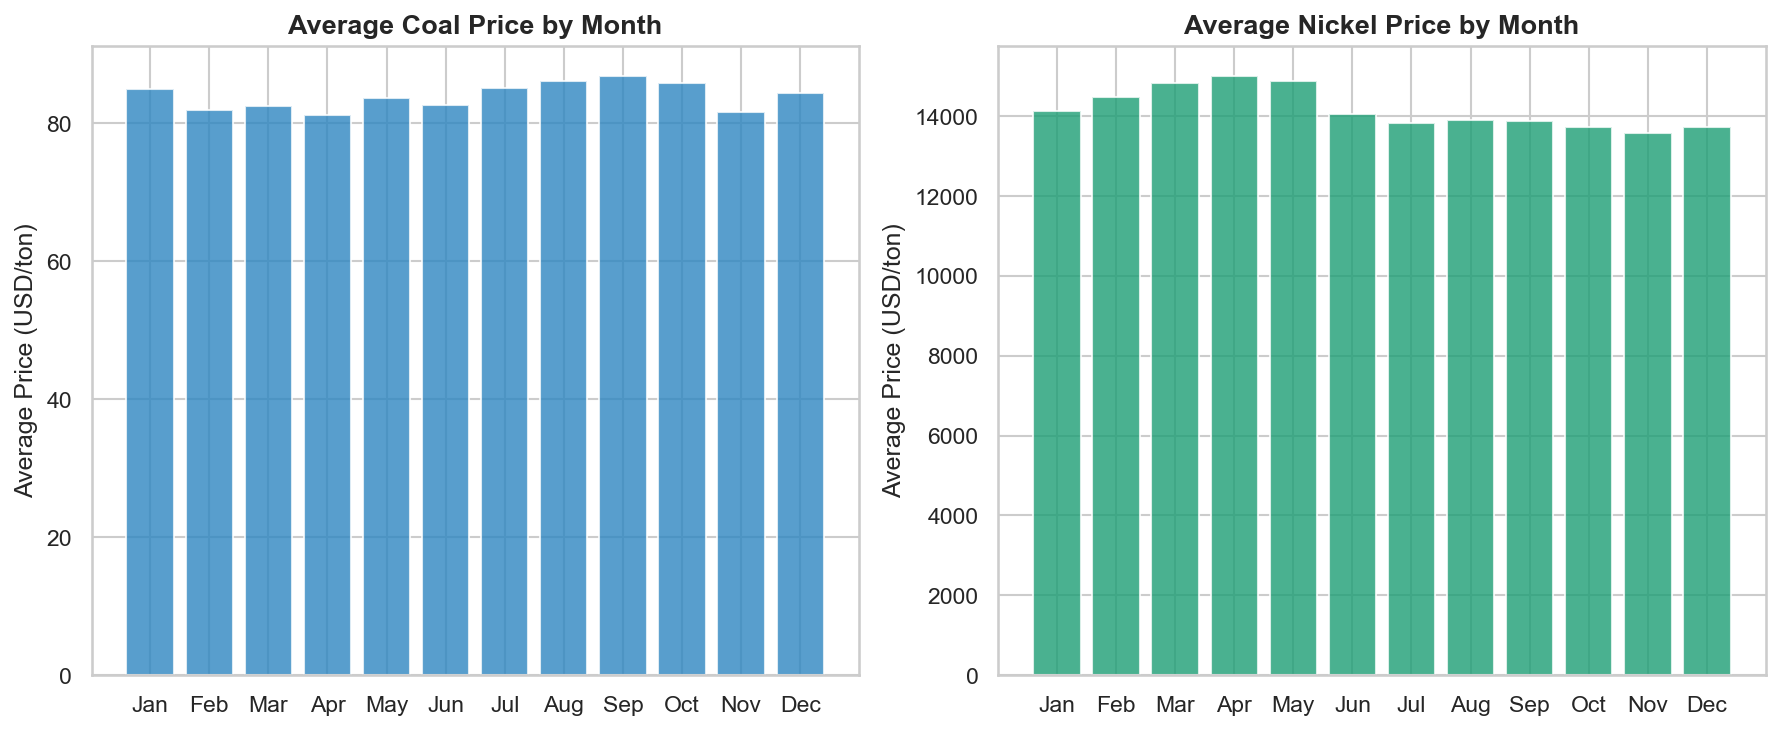

Chart 6 saved


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

coal_seasonal = df.groupby('month')['coal_price_usd'].mean()
nickel_seasonal = df.groupby('month')['nickel_price_usd'].mean()

ax1.bar(range(1,13), coal_seasonal, color='#2E86C1', alpha=0.8)
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(month_names)
ax1.set_title('Average Coal Price by Month', fontsize=13, fontweight='bold')
ax1.set_ylabel('Average Price (USD/ton)')

ax2.bar(range(1,13), nickel_seasonal, color='#1D9E75', alpha=0.8)
ax2.set_xticks(range(1,13))
ax2.set_xticklabels(month_names)
ax2.set_title('Average Nickel Price by Month', fontsize=13, fontweight='bold')
ax2.set_ylabel('Average Price (USD/ton)')

plt.tight_layout()
plt.savefig('../charts/06_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved")

## Chart 6. Seasonal Price Patterns by Month

**What I see:** Coal prices historically peak in September and January, 
aligning with the Northern Hemisphere's pre-winter energy stockpiling 
season and post-New Year industrial restocking. Nickel prices peak 
in May, likely driven by pre-summer manufacturing activity in 
major consuming countries.

**Key observation:** Both commodities show clear seasonal patterns 
that repeat consistently across decades. This seasonality is 
exploitable. buyers and sellers who understand these patterns 
can time contracts and shipments more profitably.

**Business implication:** Indonesian coal exporters should 
prioritize contract negotiations and spot sales in Q3 (July–September) 
to capture September price peaks. Nickel producers should target 
Q1–Q2 delivery contracts to align with the May price peak, 
maximizing revenue per ton shipped.